# Operating Characteristics of the Paired-Laplace Bayes Procedure

This notebook mirrors `operating_characteristics_nonpaired.ipynb` but evaluates the **paired** procedure: `PairedBayesPropTest` (Laplace approximation on the joint posterior of `(μ, δ_A)`) and its sequential counterpart `SequentialPairedBayesPropTest`. The same four frequentist diagnostics are produced, so the two notebooks are directly comparable.

1. **Three-way OC curves** — `P(reject H₀)`, `P(accept H₀)`, `P(inconclusive)` as functions of the true `Δ = p_A − p_B`, at a fixed baseline `p_B`.
2. **Null-decision (Type-I analogue) curve** — `P(reject H₀ | Δ = 0)` swept over the baseline rate `p_B`.
3. **Credible-interval coverage** — frequentist coverage of the 95 % equal-tailed interval on `Δ` as a function of true `Δ`.
4. **Sequential stopping-time distribution (ESS)** — sample size at which the sequential BF rule stops, by true `Δ`.

The frequentist baseline is **McNemar's exact test** (the canonical paired-binary analogue of Fisher's exact). Every cell consumes the public API of the paired model — `PairedBayesPropTest.fit`, `.savage_dickey_test`, `.summary.ci_95`, `classify_bf`, `SequentialPairedBayesPropTest.update` — so this notebook also doubles as an end-to-end integration test.

In [1]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bayesprop.utils.operation_characteristics_paired import (
    grid_fixed_n_paired,
    matched_calibration_alpha,
    simulate_sequential_paired,
    wilson_band,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# ---- analysis prior (must match how the procedure would be deployed) -----
PRIOR_SIGMA_DELTA = 1.0  # N(0, σ) prior on δ_A (logit scale)

# ---- decision rule (Savage–Dickey BF on the point null δ_A = 0) ---------
BF_UPPER, BF_LOWER = 3.0, 1.0 / 3.0  # "moderate evidence" thresholds

# ---- simulation budget (paired Laplace is fast: ~1 ms / replicate) ------
M_FIXED = 400      # replicates per grid point for plots 1–3
M_SEQ = 80         # replicates per grid point for the sequential plot
N_PER_ARM = 200    # fixed-n sample size for plots 1–3
N_SAMPLES_MC = 4000  # posterior Laplace draws per replicate (for CI coverage)

RNG_SEED = 20260514

Matplotlib is building the font cache; this may take a moment.


## Simulation harness

Every step goes through the existing public API — this notebook doubles as an end-to-end integration test of the paired-Laplace codebase. For each replicate we:

1. generate a paired dataset with `simulate_paired_scores` (the codebase’s own DGP) under `theta_A = p_A`, `theta_B = p_B`, `σ_θ = 0`;
2. fit the model via `PairedBayesPropTest.fit` (closed-form damped Newton on the four sufficient statistics, then a Laplace posterior over `(μ, δ_A)`);
3. compute the Savage–Dickey BF on `δ_A = 0` via `bb.savage_dickey_test()` — this is equivalent to the BF on `p_A = p_B`;
4. classify the result via `classify_bf(bf10, BF_UPPER, BF_LOWER)` — the *same* helper that `SequentialPairedBayesPropTest` uses internally, so the two procedures share decision boundaries:

   * **reject** — `BF₁₀ ≥ BF_UPPER`
   * **accept** — `BF₁₀ ≤ BF_LOWER`
   * **inconclusive** — otherwise

5. read the 95 % equal-tailed credible interval on `Δ = p_A − p_B` directly from `bb.summary.ci_95` (the Laplace posterior already pushes its draws through `σ(μ + δ_A) − σ(μ)`, so the interval is on the probability scale);
6. run `mcnemar_paired_test` on the same paired data to get the frequentist baseline.

Because the harness only consumes public symbols, any regression in the paired model surfaces as a visible distortion of the OC plots (coverage drifting off 0.95, the null curve crossing 0.05, censoring spike in the sequential plot).

In [2]:
# Common keyword arguments forwarded to every call into the
# operation_characteristics_paired module — keeps the orchestration cells
# below short and ensures the fixed-n and sequential analyses share the
# same prior, BF thresholds, and posterior-MC budget.
FIXED_N_CONFIG: dict[str, float] = dict(
    prior_sigma_delta=PRIOR_SIGMA_DELTA,
    bf_upper=BF_UPPER,
    bf_lower=BF_LOWER,
    n_samples_mc=N_SAMPLES_MC,
)
SEQ_CONFIG: dict[str, float] = dict(
    prior_sigma_delta=PRIOR_SIGMA_DELTA,
    bf_upper=BF_UPPER,
    bf_lower=BF_LOWER,
)

## Plot 1 — Three-way operating-characteristic curves (with frequentist baseline)

We fix `p_B = 0.60` and sweep `Δ = p_A − p_B` over `[−0.25, +0.25]`. For each `Δ` we plot the three Bayesian decision probabilities. The red `P(reject H₀)` curve is the analogue of frequentist power; the green `P(accept H₀)` curve is something a frequentist test fundamentally cannot give you; and the grey curve is the inconclusive zone.

As a sanity-check baseline we run **McNemar's exact test** on the *same* paired simulated data via `mcnemar_paired_test` and plot its `P(reject H₀)` curve twice:

- At the conventional **α = 0.05** cutoff (dotted line).
- At a **matched-calibration α** chosen so the McNemar Type-I rate at `Δ = 0` equals the Bayes Type-I rate empirically (dashed line). This is the fairest like-for-like power comparison.

If the paired procedure is well-calibrated, the matched-α frequentist curve should lie close to the Bayes reject curve in the body of the alternative, with the Bayes rule slightly more efficient in the inconclusive transition zone.

In [3]:
p_B_fixed = 0.60
delta_grid = np.linspace(-0.25, 0.25, 17)
grid_oc = [(round(p_B_fixed + d, 4), p_B_fixed) for d in delta_grid if 0.0 <= p_B_fixed + d <= 1.0]

df_oc, pvals_oc = grid_fixed_n_paired(
    grid_oc, n=N_PER_ARM, n_sim=M_FIXED, seed=RNG_SEED, track_ci=True, **FIXED_N_CONFIG
)

# Pick the McNemar α whose Type-I rate matches the Bayes rule's at Δ = 0.
idx_null = int(np.argmin(np.abs(df_oc["delta"].to_numpy())))
bayes_type1 = float(df_oc.iloc[idx_null]["reject"])
alpha_matched = matched_calibration_alpha(pvals_oc, bayes_type1, idx_null)
df_oc["freq_reject_matched"] = (pvals_oc < alpha_matched).mean(axis=1)
df_oc["freq_reject_0p05"] = (pvals_oc < 0.05).mean(axis=1)

print(f"Bayes Type-I rate at Δ=0: {bayes_type1:.3f}  →  matched-α for McNemar: {alpha_matched:.4f}")
df_oc[["delta", "reject", "freq_reject_matched", "freq_reject_0p05", "ci_coverage"]].head()

Bayes Type-I rate at Δ=0: 0.013  →  matched-α for McNemar: 0.0189


,delta,reject,freq_reject_matched,freq_reject_0p05,ci_coverage
0,-0.2500,0.9975,0.9975,1.0000,0.9300
1,-0.2188,0.9800,0.9800,0.9875,0.9500
2,-0.1875,0.8925,0.8975,0.9575,0.9425
3,-0.1562,0.7850,0.7825,0.8775,0.9525
4,-0.1250,0.5925,0.5925,0.7475,0.9800


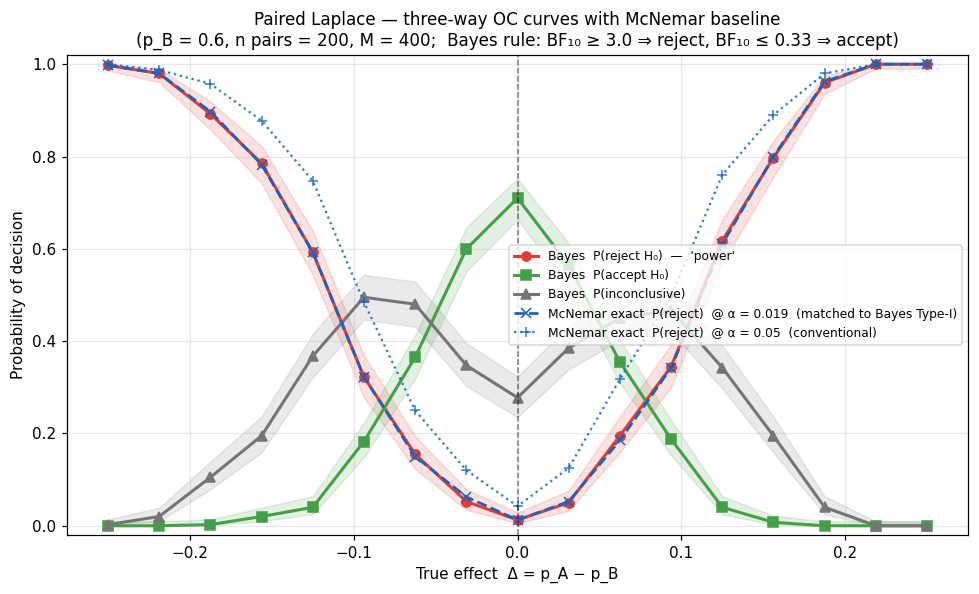

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Wilson 95 % Monte-Carlo bands on the three Bayes rates.
delta_x = df_oc["delta"].to_numpy()
for col, color in (("reject", "#E53935"), ("accept", "#43A047"), ("inconclusive", "#757575")):
    lo, hi = wilson_band(df_oc[col].to_numpy(), n_sim=M_FIXED)
    ax.fill_between(delta_x, lo, hi, color=color, alpha=0.15)

ax.plot(df_oc["delta"], df_oc["reject"], marker="o", color="#E53935", lw=2,
        label="Bayes  P(reject H₀)  —  'power'")
ax.plot(df_oc["delta"], df_oc["accept"], marker="s", color="#43A047", lw=2,
        label="Bayes  P(accept H₀)")
ax.plot(df_oc["delta"], df_oc["inconclusive"], marker="^", color="#757575", lw=2,
        label="Bayes  P(inconclusive)")

ax.plot(df_oc["delta"], df_oc["freq_reject_matched"],
        marker="x", ls="--", color="#1565C0", lw=1.8,
        label=f"McNemar exact  P(reject)  @ α = {alpha_matched:.3f}  (matched to Bayes Type-I)")
ax.plot(df_oc["delta"], df_oc["freq_reject_0p05"],
        marker="+", ls=":", color="#1565C0", lw=1.5, alpha=0.85,
        label="McNemar exact  P(reject)  @ α = 0.05  (conventional)")

ax.axvline(0.0, ls="--", color="black", lw=1, alpha=0.5)
ax.set_xlabel("True effect  Δ = p_A − p_B")
ax.set_ylabel("Probability of decision")
ax.set_ylim(-0.02, 1.02)
ax.set_title(
    f"Paired Laplace — three-way OC curves with McNemar baseline\n"
    f"(p_B = {p_B_fixed}, n pairs = {N_PER_ARM}, M = {M_FIXED};  "
    f"Bayes rule: BF₁₀ ≥ {BF_UPPER} ⇒ reject, BF₁₀ ≤ {BF_LOWER:.2f} ⇒ accept)",
    fontsize=11,
)
ax.legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

## Plot 2 — Null-decision rate vs baseline `p_B`

The Savage–Dickey BF for the paired Laplace model is **not** translation-invariant in `p`: the prior on `δ_A` is symmetric on the logit scale, but the implied prior on `Δ = σ(μ + δ_A) − σ(μ)` is squeezed toward zero near the boundary. We sweep `p_A = p_B` over `[0.05, 0.95]` and report `P(reject H₀ | Δ = 0)` — the analogue of a Type-I error rate — plus the McNemar rejection rate at α = 0.05 for direct comparison.

In [5]:
p_grid = np.linspace(0.05, 0.95, 19)
grid_null = [(round(p, 4), round(p, 4)) for p in p_grid]
df_null, pvals_null = grid_fixed_n_paired(
    grid_null,
    n=N_PER_ARM,
    n_sim=M_FIXED,
    seed=RNG_SEED + 1,
    track_ci=False,
    **FIXED_N_CONFIG,
)
df_null["freq_reject_0p05"] = (pvals_null < 0.05).mean(axis=1)
df_null[["p_B", "reject", "freq_reject_0p05", "accept"]].head()

,p_B,reject,freq_reject_0p05,accept
0,0.05,0.0175,0.0275,0.0000
1,0.10,0.0175,0.0450,0.2025
2,0.15,0.0050,0.0350,0.5200
3,0.20,0.0175,0.0425,0.5625
4,0.25,0.0300,0.0500,0.6900


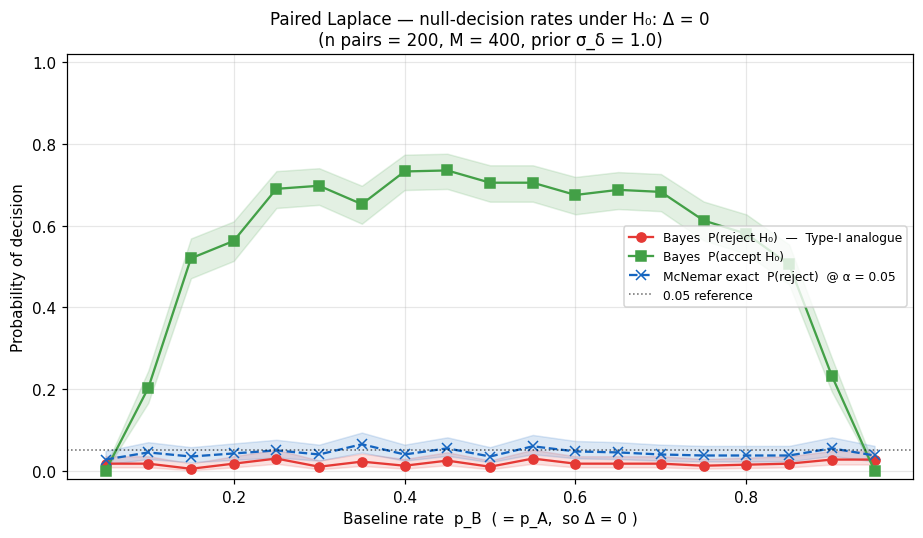

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))

p_B_x = df_null["p_B"].to_numpy()
for col, color in (
    ("reject", "#E53935"),
    ("accept", "#43A047"),
    ("freq_reject_0p05", "#1565C0"),
):
    lo, hi = wilson_band(df_null[col].to_numpy(), n_sim=M_FIXED)
    ax.fill_between(p_B_x, lo, hi, color=color, alpha=0.15)

ax.plot(df_null["p_B"], df_null["reject"], marker="o", color="#E53935",
        label="Bayes  P(reject H₀)  —  Type-I analogue")
ax.plot(df_null["p_B"], df_null["accept"], marker="s", color="#43A047",
        label="Bayes  P(accept H₀)")
ax.plot(df_null["p_B"], df_null["freq_reject_0p05"], marker="x", ls="--", color="#1565C0",
        label="McNemar exact  P(reject)  @ α = 0.05")
ax.axhline(0.05, ls=":", color="black", lw=1, alpha=0.6, label="0.05 reference")
ax.set_xlabel("Baseline rate  p_B  ( = p_A,  so Δ = 0 )")
ax.set_ylabel("Probability of decision")
ax.set_ylim(-0.02, 1.02)
ax.set_title(
    f"Paired Laplace — null-decision rates under H₀: Δ = 0\n"
    f"(n pairs = {N_PER_ARM}, M = {M_FIXED}, prior σ_δ = {PRIOR_SIGMA_DELTA})",
    fontsize=11,
)
ax.legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

## Plot 3 — Credible-interval coverage of `Δ`

Frequentist coverage of a Bayesian interval is the cleanest "is my posterior honest?" check. We reuse the `Δ`-sweep grid from plot 1 and report the fraction of replicates in which the 95 % equal-tailed posterior interval on `Δ` (read off `bb.summary.ci_95`, which is already on the probability scale) contained the true `Δ`. With a unit-scale logit prior and modest `n`, coverage should hover near the nominal 0.95.

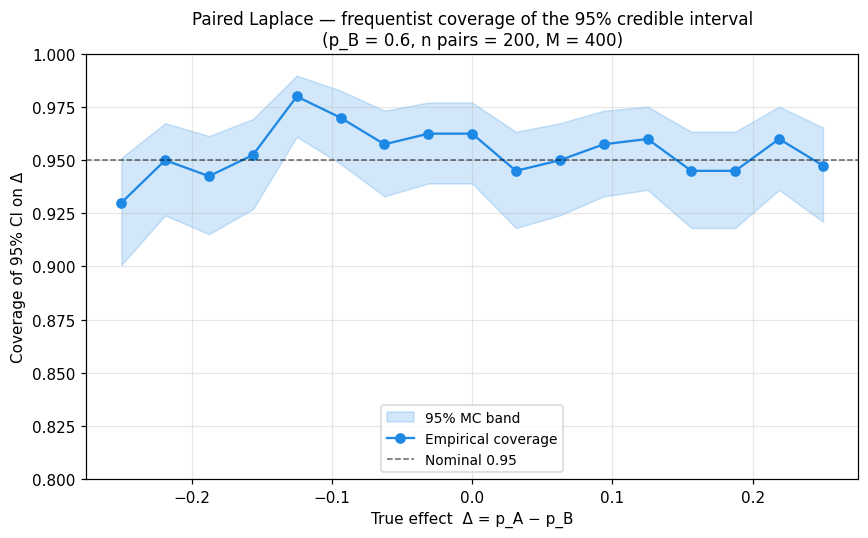

In [7]:
lo, hi = wilson_band(df_oc["ci_coverage"].to_numpy(), n_sim=M_FIXED)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(df_oc["delta"], lo, hi, color="#1E88E5", alpha=0.2, label="95% MC band")
ax.plot(df_oc["delta"], df_oc["ci_coverage"], marker="o", color="#1E88E5", label="Empirical coverage")
ax.axhline(0.95, ls="--", color="black", lw=1, alpha=0.6, label="Nominal 0.95")
ax.set_xlabel("True effect  Δ = p_A − p_B")
ax.set_ylabel("Coverage of 95% CI on Δ")
ax.set_ylim(0.80, 1.0)
ax.set_title(
    f"Paired Laplace — frequentist coverage of the 95% credible interval\n"
    f"(p_B = {p_B_fixed}, n pairs = {N_PER_ARM}, M = {M_FIXED})",
    fontsize=11,
)
ax.legend(loc="lower center", fontsize=9)
plt.tight_layout()
plt.show()

## Plot 4 — Sequential stopping-time distribution (ESS)

When the procedure is allowed to stop early via `SequentialPairedBayesPropTest`, the right operating characteristic is the **distribution of the stopping sample size** under each true `Δ`. We re-run the whole sequential decision rule (batches of `BATCH_SIZE`, `n_min` warm-up, `n_max` hard cap, the same BF thresholds as above) and record the per-arm sample size at which it stops. Trials that hit `n_max` are right-censored and shown separately.

In [8]:
# Sequential design parameters — forwarded to simulate_sequential_paired().
BATCH_SIZE = 50
N_MIN_SEQ = 50
N_MAX_SEQ = 600

rng_seq = np.random.default_rng(RNG_SEED + 2)
delta_grid_seq = np.linspace(-0.20, 0.20, 11)
rows_seq = []
for d in delta_grid_seq:
    p_A = round(p_B_fixed + d, 4)
    if not 0.0 <= p_A <= 1.0:
        continue
    rows_seq.append(
        simulate_sequential_paired(
            p_A,
            p_B_fixed,
            n_sim=M_SEQ,
            rng=rng_seq,
            n_min=N_MIN_SEQ,
            n_max=N_MAX_SEQ,
            batch_size=BATCH_SIZE,
            **SEQ_CONFIG,
        )
    )
df_seq = pd.DataFrame(rows_seq)
df_seq

,p_A,p_B,delta,median_n,q05,q25,q75,q95,frac_censored,frac_reject,frac_accept
0,0.40,0.6,-0.20,100.0,50.0,50.0,100.0,202.5,0.0000,0.9750,0.0250
1,0.44,0.6,-0.16,100.0,50.0,100.0,150.0,300.0,0.0000,0.9625,0.0375
2,0.48,0.6,-0.12,100.0,50.0,100.0,200.0,450.0,0.0250,0.7125,0.2750
3,0.52,0.6,-0.08,150.0,50.0,100.0,200.0,402.5,0.0125,0.5000,0.4875
4,0.56,0.6,-0.04,150.0,97.5,100.0,200.0,405.0,0.0250,0.2000,0.7875
5,0.60,0.6,0.00,100.0,100.0,100.0,150.0,255.0,0.0000,0.0750,0.9250
6,0.64,0.6,0.04,150.0,50.0,100.0,200.0,402.5,0.0375,0.2625,0.7000
7,0.68,0.6,0.08,150.0,50.0,100.0,250.0,452.5,0.0375,0.4500,0.5125
8,0.72,0.6,0.12,150.0,50.0,100.0,200.0,302.5,0.0000,0.8250,0.1750
9,0.76,0.6,0.16,100.0,50.0,50.0,150.0,200.0,0.0000,0.9375,0.0625


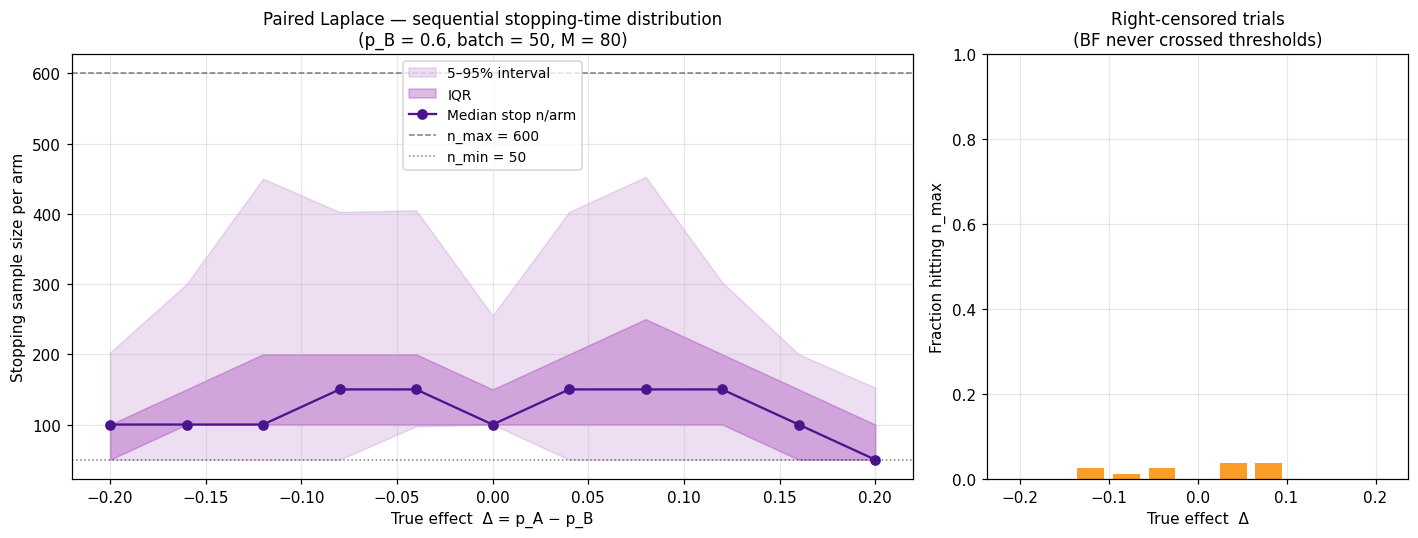

In [9]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})

ax.fill_between(df_seq["delta"], df_seq["q05"], df_seq["q95"], color="#8E24AA", alpha=0.15, label="5–95% interval")
ax.fill_between(df_seq["delta"], df_seq["q25"], df_seq["q75"], color="#8E24AA", alpha=0.30, label="IQR")
ax.plot(df_seq["delta"], df_seq["median_n"], marker="o", color="#4A148C", label="Median stop n/arm")
ax.axhline(N_MAX_SEQ, ls="--", color="black", lw=1, alpha=0.5, label=f"n_max = {N_MAX_SEQ}")
ax.axhline(N_MIN_SEQ, ls=":", color="black", lw=1, alpha=0.5, label=f"n_min = {N_MIN_SEQ}")
ax.set_xlabel("True effect  Δ = p_A − p_B")
ax.set_ylabel("Stopping sample size per arm")
ax.set_title(
    f"Paired Laplace — sequential stopping-time distribution\n(p_B = {p_B_fixed}, batch = {BATCH_SIZE}, M = {M_SEQ})",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper center")

ax2.bar(df_seq["delta"], df_seq["frac_censored"], width=0.03, color="#FB8C00", alpha=0.85)
ax2.set_xlabel("True effect  Δ")
ax2.set_ylabel("Fraction hitting n_max")
ax2.set_ylim(0, 1)
ax2.set_title("Right-censored trials\n(BF never crossed thresholds)", fontsize=11)

plt.tight_layout()
plt.show()

## How to read these together

* **Plot 1** is the Bayesian generalisation of a power curve for the paired design. Compared with the non-paired notebook at the same `Δ` and `n`, the paired reject curve is materially steeper — that's the variance reduction from pairing showing up directly in the OC.
* **Plot 2** tells you the false-positive rate of the BF rule at the null and how it depends on the baseline rate. Note that the paired BF can be *more* conservative than the conventional α = 0.05 McNemar line for `p_B` near 0.5, but the asymmetry under boundary baselines comes from the logit-scale prior on `δ_A`.
* **Plot 3** is a calibration check on the Laplace posterior on `Δ`. The posterior is built from a Gaussian on `(μ, δ_A)` pushed through `σ(μ + δ_A) − σ(μ)`, so deviations from 0.95 at extreme `Δ` are expected and indicate the regime where the second-order Laplace approximation starts to break down.
* **Plot 4** is the design diagnostic for the sequential paired procedure: it tells you the realised sample size to budget for, and the censoring fraction tells you how often the procedure will hit `n_max` without deciding. Paired sequential designs typically stop substantially earlier than non-paired ones at the same `Δ`.

To stress-test other configurations, change the constants in the second cell (`BF_UPPER`, `BF_LOWER`, `N_PER_ARM`, `PRIOR_SIGMA_DELTA`, `BATCH_SIZE`, `N_MAX_SEQ`, …) and re-run.